# Report 1 : Central obesity beyond BMI: Does waist circumference improve identification of higher systolic blood pressure in U.S. adults?

In [2]:
import numpy as np
import pandas as pd
from statsmodels.gam.api import GLMGam, BSplines
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess
from matplotlib.backends.backend_pdf import PdfPages
from read import *

N (analysis sample) = 4361
                mean        std           min         max
sbp_mean  125.941756  19.715964  7.266667e+01  238.000000
RIDAGEYR   49.561798  18.410468  1.800000e+01   80.000000
BMXBMI     29.537216   7.158143  1.480000e+01   65.300000
BMXWAIST  100.144715  17.261435  5.640000e+01  169.500000
whr         0.936564   0.082234  6.627424e-01    1.238372
INDFMPIR    2.545237   1.613701  5.397605e-79    5.000000

Model comparison (higher adj_R2 better; lower AIC/BIC better):
         model     n    adj_R2           AIC           BIC
0   Base (BMI)  4361  0.272682  37000.488702  37057.912812
1  BMI + waist  4361  0.272807  37000.735914  37064.540481
2    BMI + WHR  4361  0.275283  36985.863521  37049.668087

Key coefficients (robust SE):
Waist model: waist coef = 0.05738822042441055 p = 0.2104027385684939
WHR model:   whr coef   = 17.687737031931874 p = 4.113813869262552e-05

Spline waist model vs linear waist model:
                  model     n    adj_R2           AIC

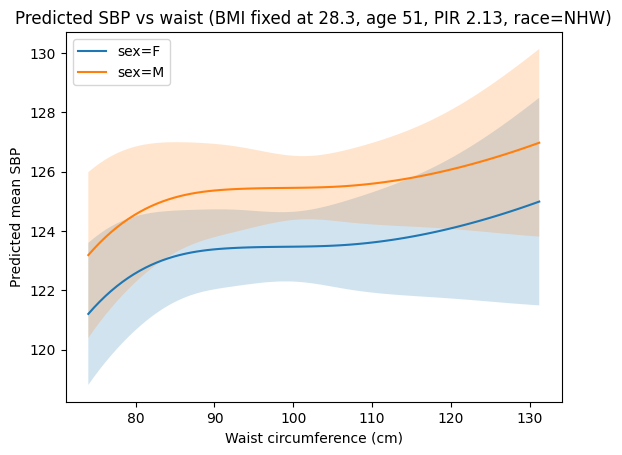

In [17]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from patsy import bs
import matplotlib.pyplot as plt

# -------------------------
# 0) Quick prep / cleaning
# -------------------------
d = df.copy()

# Adult only
d = d.loc[d["RIDAGEYR"] >= 18].copy()

# Sex + race as categorical (strings)
d["sex"] = d["RIAGENDR"].replace({1: "M", 2: "F"})
d["race"] = d["RIDRETH1"].replace({1: "MA", 2: "OH", 3: "NHW", 4: "NHB", 5: "Other"})

# SBP: use mean of repeated measures if available
sbp_cols = [c for c in ["BPXSY1", "BPXSY2", "BPXSY3", "BPXSY4"] if c in d.columns]
d["sbp_mean"] = d[sbp_cols].mean(axis=1, skipna=True)

# WHR
d["whr"] = d["BMXWAIST"] / d["BMXHIP"]

# Keep only complete cases for core variables
core_vars = ["sbp_mean", "RIDAGEYR", "sex", "race", "INDFMPIR", "BMXBMI", "BMXWAIST", "whr"]
d = d.dropna(subset=core_vars).copy()

# Basic sanity filters (optional but helpful)
d = d.loc[(d["sbp_mean"].between(70, 250)) & (d["BMXBMI"].between(12, 70))].copy()
d = d.loc[(d["BMXWAIST"].between(40, 200)) & (d["whr"].between(0.5, 1.5))].copy()

print("N (analysis sample) =", len(d))
print(d[["sbp_mean","RIDAGEYR","BMXBMI","BMXWAIST","whr","INDFMPIR"]].describe().T[["mean","std","min","max"]])

# -------------------------------------------
# 1) Does waist add beyond BMI? (linear OLS)
# -------------------------------------------
f_base = "sbp_mean ~ RIDAGEYR + C(sex) + C(race) + INDFMPIR + BMXBMI"
f_waist = "sbp_mean ~ RIDAGEYR + C(sex) + C(race) + INDFMPIR + BMXBMI + BMXWAIST"
f_whr   = "sbp_mean ~ RIDAGEYR + C(sex) + C(race) + INDFMPIR + BMXBMI + whr"

m_base  = smf.ols(f_base, data=d).fit(cov_type="HC3")
m_waist = smf.ols(f_waist, data=d).fit(cov_type="HC3")
m_whr   = smf.ols(f_whr, data=d).fit(cov_type="HC3")

def model_card(name, m):
    return {
        "model": name,
        "n": int(m.nobs),
        "adj_R2": float(m.rsquared_adj),
        "AIC": float(m.aic),
        "BIC": float(m.bic),
    }

summary_tbl = pd.DataFrame([
    model_card("Base (BMI)", m_base),
    model_card("BMI + waist", m_waist),
    model_card("BMI + WHR", m_whr),
])
print("\nModel comparison (higher adj_R2 better; lower AIC/BIC better):")
print(summary_tbl)

print("\nKey coefficients (robust SE):")
print("Waist model: waist coef =", m_waist.params.get("BMXWAIST", np.nan), 
      "p =", m_waist.pvalues.get("BMXWAIST", np.nan))
print("WHR model:   whr coef   =", m_whr.params.get("whr", np.nan), 
      "p =", m_whr.pvalues.get("whr", np.nan))

# ---------------------------------------------------
# 2) Nonlinearity: spline for waist (keep BMI linear)
# ---------------------------------------------------
f_waist_spline = "sbp_mean ~ RIDAGEYR + C(sex) + C(race) + INDFMPIR + BMXBMI + bs(BMXWAIST, df=5)"
m_waist_spline = smf.ols(f_waist_spline, data=d).fit(cov_type="HC3")

print("\nSpline waist model vs linear waist model:")
print(pd.DataFrame([
    model_card("BMI + waist (linear)", m_waist),
    model_card("BMI + waist (spline)", m_waist_spline),
]))

# -------------------------------------------------------
# 3) Interaction: does waist-SBP differ by sex?
# (Use linear interaction first; spline interaction is heavier.)
# -------------------------------------------------------
f_waist_int = "sbp_mean ~ RIDAGEYR + C(sex) + C(race) + INDFMPIR + BMXBMI + BMXWAIST * C(sex)"
m_waist_int = smf.ols(f_waist_int, data=d).fit(cov_type="HC3")

print("\nInteraction check (waist*sex):")
# the interaction term name depends on coding; list terms containing waist:C(sex)
int_terms = [k for k in m_waist_int.params.index if "BMXWAIST:C(sex)" in k]
print("Interaction terms:", int_terms)
for t in int_terms:
    print(t, "coef =", m_waist_int.params[t], "p =", m_waist_int.pvalues[t])

print("\nModel comparison (linear waist vs waist*sex):")
print(pd.DataFrame([
    model_card("BMI + waist (linear)", m_waist),
    model_card("BMI + waist*sex", m_waist_int),
]))

# -------------------------------------------------------
# 4) Plot: predicted SBP vs waist at fixed BMI and covars
# -------------------------------------------------------
# pick "typical" covariate values from data
age0  = float(d["RIDAGEYR"].median())
pir0  = float(d["INDFMPIR"].median())
bmi0  = float(d["BMXBMI"].median())
race0 = d["race"].value_counts().idxmax()

w_lo, w_hi = d["BMXWAIST"].quantile([0.05, 0.95]).tolist()
waist_grid = np.linspace(w_lo, w_hi, 80)

pred_frames = []
for sx in ["F", "M"]:
    tmp = pd.DataFrame({
        "RIDAGEYR": age0,
        "sex": sx,
        "race": race0,
        "INDFMPIR": pir0,
        "BMXBMI": bmi0,
        "BMXWAIST": waist_grid
    })
    # must match formula variable names: C(sex), C(race) refer to 'sex' and 'race'
    pred = m_waist_spline.get_prediction(tmp).summary_frame()
    tmp["pred"] = pred["mean"].values
    tmp["lo"]   = pred["mean_ci_lower"].values
    tmp["hi"]   = pred["mean_ci_upper"].values
    pred_frames.append(tmp)

pp = pd.concat(pred_frames, ignore_index=True)

plt.figure()
for sx, g in pp.groupby("sex"):
    plt.plot(g["BMXWAIST"], g["pred"], label=f"sex={sx}")
    plt.fill_between(g["BMXWAIST"], g["lo"], g["hi"], alpha=0.2)

plt.xlabel("Waist circumference (cm)")
plt.ylabel("Predicted mean SBP")
plt.title(f"Predicted SBP vs waist (BMI fixed at {bmi0:.1f}, age {age0:.0f}, PIR {pir0:.2f}, race={race0})")
plt.legend()
plt.show()

N (analysis sample) = 4361
                mean        std           min         max
sbp_mean  125.941756  19.715964  7.266667e+01  238.000000
RIDAGEYR   49.561798  18.410468  1.800000e+01   80.000000
BMXBMI     29.537216   7.158143  1.480000e+01   65.300000
BMXWAIST  100.144715  17.261435  5.640000e+01  169.500000
BMXHIP    106.701812  14.501153  7.470000e+01  179.000000
whr         0.936564   0.082234  6.627424e-01    1.238372
INDFMPIR    2.545237   1.613701  5.397605e-79    5.000000

Model comparison (higher adj_R2 better; lower AIC/BIC better):
           model     n    adj_R2           AIC           BIC
0     Base (BMI)  4361  0.272682  37000.488702  37057.912812
1      BMI + WHR  4361  0.275283  36985.863521  37049.668087
2  BMI + WHR*sex  4361  0.283203  36938.937929  37009.122952

Key coefficient (robust SE):
WHR main effect (BMI+WHR): coef = 17.687737031931874 p = 4.113813869262552e-05

Interaction terms (whr*sex): ['whr:C(sex)[T.M]']
whr:C(sex)[T.M] coef = -48.6720301626286 p

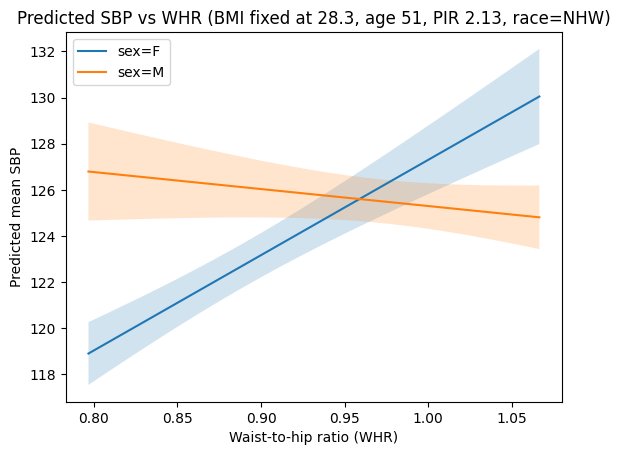


Stratified descriptive check: Mean SBP across WHR tertiles within BMI groups
   bmi_group whr_tertile_within_bmi   n   sbp_mean    sbp_sd  mean_whr  mean_waist  mean_bmi
Normal/Under                Low WHR 403 111.804797 14.246156  0.799399   74.619355 21.109181
Normal/Under                Mid WHR 403 121.937965 19.396684  0.875677   81.340447 22.021092
Normal/Under               High WHR 403 131.347395 21.759733  0.961384   89.201241 22.922581
  Overweight                Low WHR 454 120.162996 18.619497  0.865173   89.996256 27.037225
  Overweight                Mid WHR 453 126.902134 18.660054  0.948800   96.896468 27.394481
  Overweight               High WHR 454 131.704112 19.640535  1.020638  102.398458 27.652423
       Obese                Low WHR 597 125.027917 18.852185  0.885737  109.129648 36.831156
       Obese                Mid WHR 597 129.503629 19.619247  0.971077  116.071859 36.287102
       Obese               High WHR 597 131.174204 17.731419  1.050888  121.012730 35

C:\Users\oscar10408\AppData\Local\Temp\ipykernel_23620\2764170002.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  d["whr_tertile_within_bmi"] = d.groupby("bmi_group")["whr"].transform(tertiles)
C:\Users\oscar10408\AppData\Local\Temp\ipykernel_23620\2764170002.py:153: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["bmi_group", "whr_tertile_within_bmi"])
C:\Users\oscar10408\AppData\Local\Temp\ipykernel_23620\2764170002.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or obse

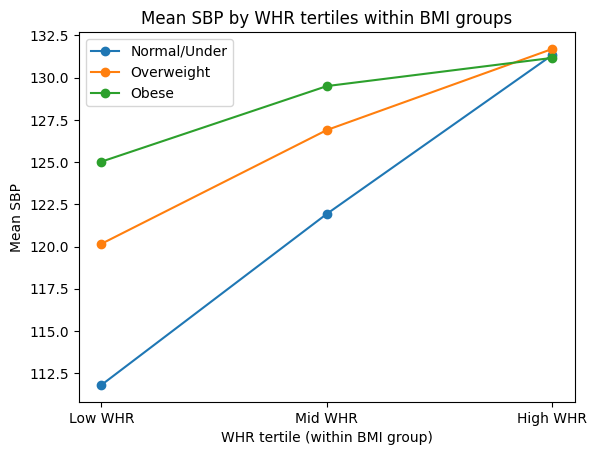

In [18]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# =========================
# 0) Put your merged df here
# =========================
# Replace `df` with your actual dataframe name
DATA = df   # <-- change this if your dataframe name is different

# -------------------------
# 1) Prep / cleaning
# -------------------------
d = DATA.copy()

# Adult only
d = d.loc[d["RIDAGEYR"] >= 18].copy()

# Categorical labels
d["sex"] = d["RIAGENDR"].replace({1: "M", 2: "F"})
d["race"] = d["RIDRETH1"].replace({1: "MA", 2: "OH", 3: "NHW", 4: "NHB", 5: "Other"})

# SBP mean from repeated measures
sbp_cols = [c for c in ["BPXSY1", "BPXSY2", "BPXSY3", "BPXSY4"] if c in d.columns]
d["sbp_mean"] = d[sbp_cols].mean(axis=1, skipna=True)

# WHR
d["whr"] = d["BMXWAIST"] / d["BMXHIP"]

# Core analysis variables
core_vars = ["sbp_mean", "RIDAGEYR", "sex", "race", "INDFMPIR", "BMXBMI", "BMXWAIST", "BMXHIP", "whr"]
d = d.dropna(subset=core_vars).copy()

# Basic sanity filters (keep these mild)
d = d.loc[(d["sbp_mean"].between(70, 250)) & (d["BMXBMI"].between(12, 70))].copy()
d = d.loc[(d["BMXWAIST"].between(40, 200)) & (d["BMXHIP"].between(50, 220))].copy()
d = d.loc[d["whr"].between(0.5, 1.5)].copy()

print("N (analysis sample) =", len(d))
print(d[["sbp_mean","RIDAGEYR","BMXBMI","BMXWAIST","BMXHIP","whr","INDFMPIR"]].describe().T[["mean","std","min","max"]])

# -------------------------
# 2) Models: BMI vs WHR
# -------------------------
f_base = "sbp_mean ~ RIDAGEYR + C(sex) + C(race) + INDFMPIR + BMXBMI"
f_whr  = "sbp_mean ~ RIDAGEYR + C(sex) + C(race) + INDFMPIR + BMXBMI + whr"
f_whr_int = "sbp_mean ~ RIDAGEYR + C(sex) + C(race) + INDFMPIR + BMXBMI + whr * C(sex)"

m_base = smf.ols(f_base, data=d).fit(cov_type="HC3")
m_whr  = smf.ols(f_whr, data=d).fit(cov_type="HC3")
m_whr_int = smf.ols(f_whr_int, data=d).fit(cov_type="HC3")

def model_card(name, m):
    return {
        "model": name,
        "n": int(m.nobs),
        "adj_R2": float(m.rsquared_adj),
        "AIC": float(m.aic),
        "BIC": float(m.bic),
    }

summary_tbl = pd.DataFrame([
    model_card("Base (BMI)", m_base),
    model_card("BMI + WHR", m_whr),
    model_card("BMI + WHR*sex", m_whr_int),
])

print("\nModel comparison (higher adj_R2 better; lower AIC/BIC better):")
print(summary_tbl)

print("\nKey coefficient (robust SE):")
print("WHR main effect (BMI+WHR): coef =", float(m_whr.params.get("whr", np.nan)),
      "p =", float(m_whr.pvalues.get("whr", np.nan)))

# Interaction terms
int_terms = [k for k in m_whr_int.params.index if "whr:C(sex)" in k]
print("\nInteraction terms (whr*sex):", int_terms)
for t in int_terms:
    print(t, "coef =", float(m_whr_int.params[t]), "p =", float(m_whr_int.pvalues[t]))

# Interpret WHR effect in a human scale
if "whr" in m_whr.params.index:
    per_01 = 0.1 * m_whr.params["whr"]
    print(f"\nInterpretation: +0.10 WHR is associated with about {per_01:.2f} mmHg higher mean SBP (adjusted).")

# -------------------------
# 3) Plot: predicted SBP vs WHR (by sex)
# -------------------------
age0  = float(d["RIDAGEYR"].median())
pir0  = float(d["INDFMPIR"].median())
bmi0  = float(d["BMXBMI"].median())
race0 = d["race"].value_counts().idxmax()

w_lo, w_hi = d["whr"].quantile([0.05, 0.95]).tolist()
whr_grid = np.linspace(w_lo, w_hi, 150)

pred_frames = []
for sx in ["F", "M"]:
    tmp = pd.DataFrame({
        "RIDAGEYR": age0,
        "sex": sx,
        "race": race0,
        "INDFMPIR": pir0,
        "BMXBMI": bmi0,
        "whr": whr_grid
    })
    pred = m_whr_int.get_prediction(tmp).summary_frame()
    tmp["pred"] = pred["mean"].values
    tmp["lo"]   = pred["mean_ci_lower"].values
    tmp["hi"]   = pred["mean_ci_upper"].values
    pred_frames.append(tmp)

pp = pd.concat(pred_frames, ignore_index=True)

plt.figure()
for sx, g in pp.groupby("sex"):
    plt.plot(g["whr"], g["pred"], label=f"sex={sx}")
    plt.fill_between(g["whr"], g["lo"], g["hi"], alpha=0.2)

plt.xlabel("Waist-to-hip ratio (WHR)")
plt.ylabel("Predicted mean SBP")
plt.title(f"Predicted SBP vs WHR (BMI fixed at {bmi0:.1f}, age {age0:.0f}, PIR {pir0:.2f}, race={race0})")
plt.legend()
plt.show()

# -------------------------
# 4) Simple stratified check (no modeling)
#    Within each BMI group, compare mean SBP across WHR tertiles
# -------------------------
# BMI groups (standard cutoffs)
d["bmi_group"] = pd.cut(
    d["BMXBMI"],
    bins=[12, 25, 30, 70],
    labels=["Normal/Under", "Overweight", "Obese"],
    right=False,
)

# WHR tertiles within each BMI group
def tertiles(x):
    # If a group is too small or has many ties, qcut can fail; handle safely
    try:
        return pd.qcut(x, 3, labels=["Low WHR", "Mid WHR", "High WHR"])
    except ValueError:
        # fallback: cut by quantiles manually
        qs = x.quantile([0, 1/3, 2/3, 1]).values
        return pd.cut(x, bins=np.unique(qs), include_lowest=True, labels=["Low WHR", "Mid WHR", "High WHR"][:len(np.unique(qs))-1])

d["whr_tertile_within_bmi"] = d.groupby("bmi_group")["whr"].transform(tertiles)

tab = (
    d.dropna(subset=["bmi_group","whr_tertile_within_bmi"])
     .groupby(["bmi_group", "whr_tertile_within_bmi"])
     .agg(n=("sbp_mean", "size"),
          sbp_mean=("sbp_mean", "mean"),
          sbp_sd=("sbp_mean", "std"),
          mean_whr=("whr", "mean"),
          mean_waist=("BMXWAIST", "mean"),
          mean_bmi=("BMXBMI", "mean"))
     .reset_index()
)

print("\nStratified descriptive check: Mean SBP across WHR tertiles within BMI groups")
print(tab.to_string(index=False))

plt.figure()
for bg, g in tab.groupby("bmi_group"):
    plt.plot(g["whr_tertile_within_bmi"].astype(str), g["sbp_mean"], marker="o", label=str(bg))
plt.xlabel("WHR tertile (within BMI group)")
plt.ylabel("Mean SBP")
plt.title("Mean SBP by WHR tertiles within BMI groups")
plt.legend()
plt.show()

N (analysis sample) = 4361

Sex-stratified WHR effects (adjusted for age, race, PIR, BMI):
  sex     n   whr_coef  whr_per_0.10    whr_pvalue    adj_R2           AIC
0   F  2223  33.343665      3.334367  9.754496e-10  0.382775  18794.546584
1   M  2138   8.732228      0.873223  2.187059e-01  0.171940  18060.971193


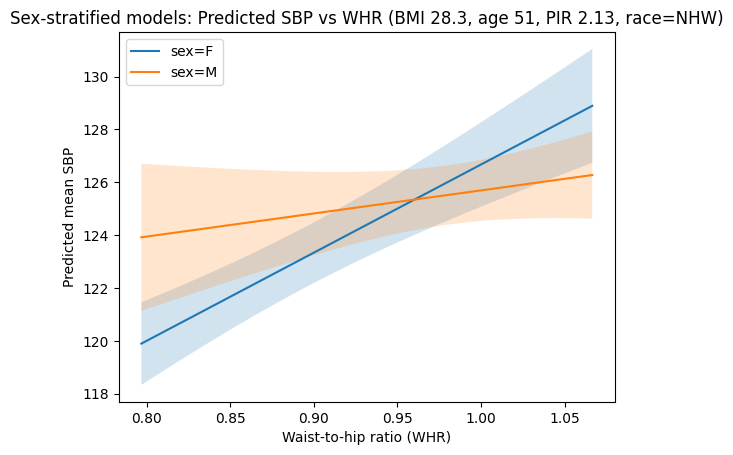


Descriptive check: Mean SBP across WHR tertiles within (sex × BMI group)
sex    bmi_group whr_tertile   n   sbp_mean    sbp_sd  mean_whr  mean_bmi  mean_waist   mean_hip
  F Normal/Under         Low 219 110.476408 15.031290  0.782469 20.962100   73.483562  93.935160
  F Normal/Under         Mid 218 116.117737 18.039068  0.849516 21.733486   79.319266  93.377064
  F Normal/Under        High 219 131.124810 22.598130  0.929816 22.763927   86.582648  93.121918
  F   Overweight         Low 204 118.084967 18.556955  0.835893 27.074020   87.873529 105.210294
  F   Overweight         Mid 203 125.727422 21.747378  0.910112 27.392611   94.407389 103.734975
  F   Overweight        High 204 133.503268 21.933309  0.978326 27.532843   99.202451 101.451961
  F        Obese         Low 319 123.783699 17.827544  0.858915 37.322257  107.815987 125.597179
  F        Obese         Mid 318 128.114256 21.124584  0.928981 36.872013  113.105346 121.757233
  F        Obese        High 319 131.306165 20.746447

C:\Users\oscar10408\AppData\Local\Temp\ipykernel_23620\3888536726.py:124: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  d.groupby(["sex", "bmi_group"])["whr"]
C:\Users\oscar10408\AppData\Local\Temp\ipykernel_23620\3888536726.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["sex", "bmi_group", "whr_tertile"])
C:\Users\oscar10408\AppData\Local\Temp\ipykernel_23620\3888536726.py:158: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and sil

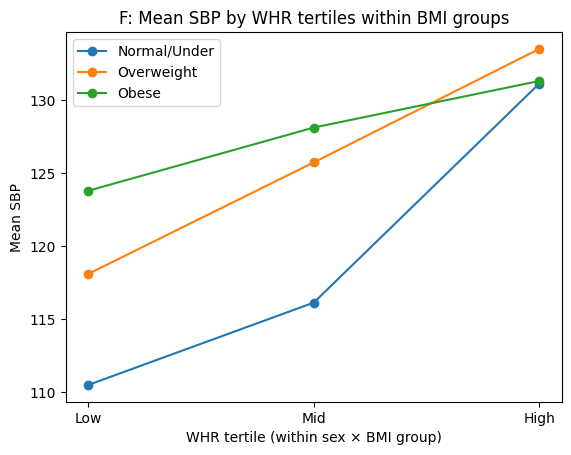

C:\Users\oscar10408\AppData\Local\Temp\ipykernel_23620\3888536726.py:158: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for bg, g in t.groupby("bmi_group"):


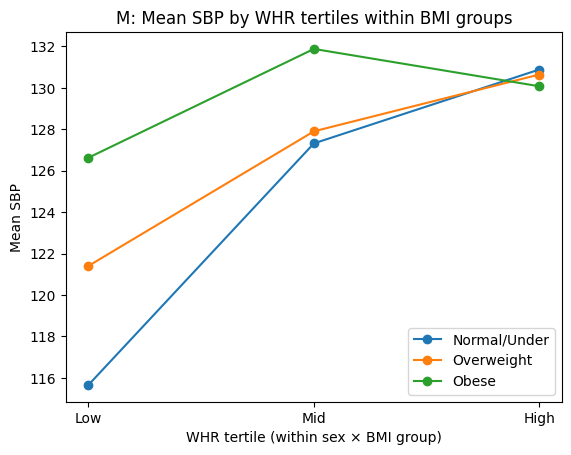

In [63]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# =========================
# 0) Put your merged df here
# =========================
DATA = df  # <-- change this if your dataframe name is different

# -------------------------
# 1) Prep / cleaning
# -------------------------
d = DATA.copy()
d = d.loc[d["RIDAGEYR"] >= 18].copy()

d["sex"] = d["RIAGENDR"].replace({1: "M", 2: "F"})
d["race"] = d["RIDRETH1"].replace({1: "MA", 2: "OH", 3: "NHW", 4: "NHB", 5: "Other"})

sbp_cols = [c for c in ["BPXSY1", "BPXSY2", "BPXSY3", "BPXSY4"] if c in d.columns]
d["sbp_mean"] = d[sbp_cols].mean(axis=1, skipna=True)

d["whr"] = d["BMXWAIST"] / d["BMXHIP"]

core_vars = ["sbp_mean", "RIDAGEYR", "sex", "race", "INDFMPIR", "BMXBMI", "BMXWAIST", "BMXHIP", "whr"]
d = d.dropna(subset=core_vars).copy()

# mild sanity filters
d = d.loc[(d["sbp_mean"].between(70, 250)) & (d["BMXBMI"].between(12, 70))].copy()
d = d.loc[(d["BMXWAIST"].between(40, 200)) & (d["BMXHIP"].between(50, 220))].copy()
d = d.loc[d["whr"].between(0.5, 1.5)].copy()

print("N (analysis sample) =", len(d))

# =============================================================================
# A)補強 1：Sex-stratified models (Female-only / Male-only)
# =============================================================================
f_strat = "sbp_mean ~ RIDAGEYR + C(race) + INDFMPIR + BMXBMI + whr"

models_by_sex = {}
coef_table = []

for sx in ["F", "M"]:
    ds = d.loc[d["sex"] == sx].copy()
    m = smf.ols(f_strat, data=ds).fit(cov_type="HC3")
    models_by_sex[sx] = m
    
    coef = float(m.params.get("whr", np.nan))
    pval = float(m.pvalues.get("whr", np.nan))
    aic  = float(m.aic)
    adjr = float(m.rsquared_adj)
    nobs = int(m.nobs)
    
    coef_table.append({
        "sex": sx,
        "n": nobs,
        "whr_coef": coef,
        "whr_per_0.10": 0.1 * coef,
        "whr_pvalue": pval,
        "adj_R2": adjr,
        "AIC": aic,
    })

coef_table = pd.DataFrame(coef_table)
print("\nSex-stratified WHR effects (adjusted for age, race, PIR, BMI):")
print(coef_table)

# Plot predicted SBP vs WHR for each sex using its own model
age0  = float(d["RIDAGEYR"].median())
pir0  = float(d["INDFMPIR"].median())
bmi0  = float(d["BMXBMI"].median())
race0 = d["race"].value_counts().idxmax()

w_lo, w_hi = d["whr"].quantile([0.05, 0.95]).tolist()
whr_grid = np.linspace(w_lo, w_hi, 150)

plt.figure()
for sx in ["F", "M"]:
    m = models_by_sex[sx]
    tmp = pd.DataFrame({
        "RIDAGEYR": age0,
        "race": race0,
        "INDFMPIR": pir0,
        "BMXBMI": bmi0,
        "whr": whr_grid
    })
    pred = m.get_prediction(tmp).summary_frame()
    plt.plot(whr_grid, pred["mean"].values, label=f"sex={sx}")
    plt.fill_between(whr_grid, pred["mean_ci_lower"].values, pred["mean_ci_upper"].values, alpha=0.2)

plt.xlabel("Waist-to-hip ratio (WHR)")
plt.ylabel("Predicted mean SBP")
plt.title(f"Sex-stratified models: Predicted SBP vs WHR (BMI {bmi0:.1f}, age {age0:.0f}, PIR {pir0:.2f}, race={race0})")
plt.legend()
plt.show()

# =============================================================================
# B)補強 2：Descriptive stratified check (BMI group × sex, WHR tertiles within each stratum)
# =============================================================================
# BMI groups (standard cutoffs)
d["bmi_group"] = pd.cut(
    d["BMXBMI"],
    bins=[12, 25, 30, 70],
    labels=["Normal/Under", "Overweight", "Obese"],
    right=False,
)

def safe_qcut_tertiles(x):
    # qcut can fail with ties or tiny groups; handle safely
    x = x.dropna()
    if len(x) < 30:  # too small to be stable; return NaNs
        return pd.Series([np.nan]*len(x), index=x.index)
    try:
        return pd.qcut(x, 3, labels=["Low", "Mid", "High"])
    except ValueError:
        qs = x.quantile([0, 1/3, 2/3, 1]).values
        bins = np.unique(qs)
        if len(bins) < 4:
            return pd.Series([np.nan]*len(x), index=x.index)
        return pd.cut(x, bins=bins, include_lowest=True, labels=["Low","Mid","High"][:len(bins)-1])

# WHR tertiles within each (sex, bmi_group)
d["whr_tertile"] = (
    d.groupby(["sex", "bmi_group"])["whr"]
     .transform(lambda s: safe_qcut_tertiles(s))
)

tab2 = (
    d.dropna(subset=["bmi_group", "whr_tertile"])
     .groupby(["sex", "bmi_group", "whr_tertile"])
     .agg(
        n=("sbp_mean", "size"),
        sbp_mean=("sbp_mean", "mean"),
        sbp_sd=("sbp_mean", "std"),
        mean_whr=("whr", "mean"),
        mean_bmi=("BMXBMI", "mean"),
        mean_waist=("BMXWAIST", "mean"),
        mean_hip=("BMXHIP", "mean"),
     )
     .reset_index()
)

print("\nDescriptive check: Mean SBP across WHR tertiles within (sex × BMI group)")
print(tab2.to_string(index=False))

# Plot: within each sex, show BMI-group lines across WHR tertiles
for sx in ["F", "M"]:
    t = tab2.loc[tab2["sex"] == sx].copy()
    if t.empty:
        continue
    
    # Ensure WHR tertiles in correct order
    order = pd.CategoricalDtype(categories=["Low", "Mid", "High"], ordered=True)
    t["whr_tertile"] = t["whr_tertile"].astype(order)
    t = t.sort_values(["bmi_group", "whr_tertile"])
    
    plt.figure()
    for bg, g in t.groupby("bmi_group"):
        plt.plot(g["whr_tertile"].astype(str), g["sbp_mean"], marker="o", label=str(bg))
    plt.xlabel("WHR tertile (within sex × BMI group)")
    plt.ylabel("Mean SBP")
    plt.title(f"{sx}: Mean SBP by WHR tertiles within BMI groups")
    plt.legend()
    plt.show()

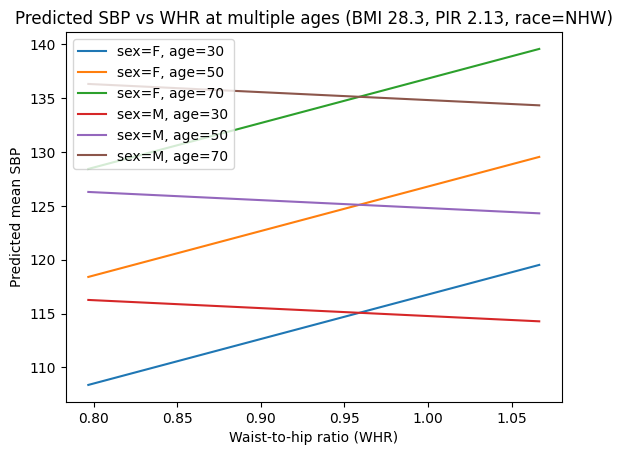

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 假設你已經有 m_whr_int（含 whr*sex）
# 固定其他 covariates 用中位數/眾數
age_levels = [30, 50, 70]  # 你也可以換成分位數
pir0  = float(d["INDFMPIR"].median())
bmi0  = float(d["BMXBMI"].median())
race0 = d["race"].value_counts().idxmax()

w_lo, w_hi = d["whr"].quantile([0.05, 0.95]).tolist()
whr_grid = np.linspace(w_lo, w_hi, 120)

plt.figure()
for sx in ["F", "M"]:
    for age0 in age_levels:
        tmp = pd.DataFrame({
            "RIDAGEYR": age0,
            "sex": sx,
            "race": race0,
            "INDFMPIR": pir0,
            "BMXBMI": bmi0,
            "whr": whr_grid
        })
        pred = m_whr_int.get_prediction(tmp).summary_frame()
        plt.plot(whr_grid, pred["mean"].values, label=f"sex={sx}, age={age0}")

plt.xlabel("Waist-to-hip ratio (WHR)")
plt.ylabel("Predicted mean SBP")
plt.title(f"Predicted SBP vs WHR at multiple ages (BMI {bmi0:.1f}, PIR {pir0:.2f}, race={race0})")
plt.legend()
plt.show()

                    spec     n    adj_R2           AIC           BIC  \
0       No PIR: BMI only  4361  0.269060  37021.155865  37072.199518   
1        No PIR: BMI+WHR  4361  0.272355  37002.447655  37059.871765   
2    No PIR: BMI+WHR*sex  4361  0.280731  36952.954725  37016.759292   
3     With PIR: BMI only  4361  0.272682  37000.488702  37057.912812   
4      With PIR: BMI+WHR  4361  0.275283  36985.863521  37049.668087   
5  With PIR: BMI+WHR*sex  4361  0.283203  36938.937929  37009.122952   

    whr_coef         whr_p      whrXsex_terms  
0        NaN           NaN                 []  
1  19.675292  4.080606e-06                 []  
2  43.776532  6.637160e-17  [whr:C(sex)[T.M]]  
3        NaN           NaN                 []  
4  17.687737  4.113814e-05                 []  
5  41.310741  5.885218e-15  [whr:C(sex)[T.M]]  

No PIR interaction terms:
whr:C(sex)[T.M] coef = -49.976728843857884 p = 1.0681278627723521e-14

With PIR interaction terms:
whr:C(sex)[T.M] coef = -48.672030

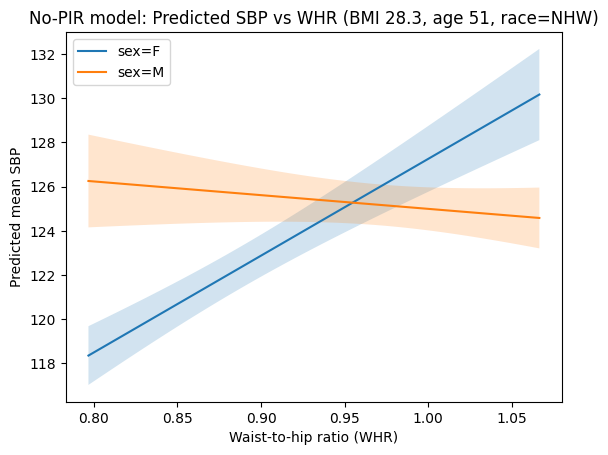

In [21]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# ---- assume d is already prepared as before (adult, sbp_mean, whr, sex, race, filters) ----
# If not, set: d = <your cleaned dataframe>

# -------------------------
# A) Models WITHOUT PIR (primary)
# -------------------------
f_base0 = "sbp_mean ~ RIDAGEYR + C(sex) + C(race) + BMXBMI"
f_whr0  = "sbp_mean ~ RIDAGEYR + C(sex) + C(race) + BMXBMI + whr"
f_int0  = "sbp_mean ~ RIDAGEYR + C(sex) + C(race) + BMXBMI + whr * C(sex)"

m_base0 = smf.ols(f_base0, data=d).fit(cov_type="HC3")
m_whr0  = smf.ols(f_whr0,  data=d).fit(cov_type="HC3")
m_int0  = smf.ols(f_int0,  data=d).fit(cov_type="HC3")

# -------------------------
# B) Models WITH PIR (sensitivity)
# -------------------------
f_base1 = "sbp_mean ~ RIDAGEYR + C(sex) + C(race) + INDFMPIR + BMXBMI"
f_whr1  = "sbp_mean ~ RIDAGEYR + C(sex) + C(race) + INDFMPIR + BMXBMI + whr"
f_int1  = "sbp_mean ~ RIDAGEYR + C(sex) + C(race) + INDFMPIR + BMXBMI + whr * C(sex)"

m_base1 = smf.ols(f_base1, data=d).fit(cov_type="HC3")
m_whr1  = smf.ols(f_whr1,  data=d).fit(cov_type="HC3")
m_int1  = smf.ols(f_int1,  data=d).fit(cov_type="HC3")

def card(tag, m):
    return {
        "spec": tag,
        "n": int(m.nobs),
        "adj_R2": float(m.rsquared_adj),
        "AIC": float(m.aic),
        "BIC": float(m.bic),
        "whr_coef": float(m.params.get("whr", np.nan)),
        "whr_p": float(m.pvalues.get("whr", np.nan)),
        "whrXsex_terms": [k for k in m.params.index if "whr:C(sex)" in k],
    }

rows = []
rows.append(card("No PIR: BMI only", m_base0))
rows.append(card("No PIR: BMI+WHR", m_whr0))
rows.append(card("No PIR: BMI+WHR*sex", m_int0))
rows.append(card("With PIR: BMI only", m_base1))
rows.append(card("With PIR: BMI+WHR", m_whr1))
rows.append(card("With PIR: BMI+WHR*sex", m_int1))

out = pd.DataFrame(rows)
print(out[["spec","n","adj_R2","AIC","BIC","whr_coef","whr_p","whrXsex_terms"]])

# Print interaction term p-values
for label, m in [("No PIR", m_int0), ("With PIR", m_int1)]:
    terms = [k for k in m.params.index if "whr:C(sex)" in k]
    print(f"\n{label} interaction terms:")
    for t in terms:
        print(t, "coef =", float(m.params[t]), "p =", float(m.pvalues[t]))

# Helpful interpretation
if "whr" in m_whr0.params.index:
    print("\nNo PIR: +0.10 WHR ->", 0.1 * float(m_whr0.params["whr"]), "mmHg (main-effect model)")
if "whr" in m_whr1.params.index:
    print("With PIR: +0.10 WHR ->", 0.1 * float(m_whr1.params["whr"]), "mmHg (main-effect model)")

# -------------------------
# C) Plot predicted SBP vs WHR (No PIR interaction model)
# -------------------------
age0  = float(d["RIDAGEYR"].median())
bmi0  = float(d["BMXBMI"].median())
race0 = d["race"].value_counts().idxmax()

w_lo, w_hi = d["whr"].quantile([0.05, 0.95]).tolist()
whr_grid = np.linspace(w_lo, w_hi, 150)

plt.figure()
for sx in ["F", "M"]:
    tmp = pd.DataFrame({
        "RIDAGEYR": age0,
        "sex": sx,
        "race": race0,
        "BMXBMI": bmi0,
        "whr": whr_grid
    })
    pred = m_int0.get_prediction(tmp).summary_frame()
    plt.plot(whr_grid, pred["mean"].values, label=f"sex={sx}")
    plt.fill_between(whr_grid, pred["mean_ci_lower"].values, pred["mean_ci_upper"].values, alpha=0.2)

plt.xlabel("Waist-to-hip ratio (WHR)")
plt.ylabel("Predicted mean SBP")
plt.title(f"No-PIR model: Predicted SBP vs WHR (BMI {bmi0:.1f}, age {age0:.0f}, race={race0})")
plt.legend()
plt.show()

# Formal Code:

N (analysis sample) = 4979

=== Baseline LM (linear WHR, with WHR*sex) ===
AIC: 42200.30208058409 adj_R2: 0.279474314134891

=== Spline/GAM-style models ===
GAM main:     AIC: 42210.8158744698 adj_R2: 0.2792514097381198
GAM + sex by: AIC: 42180.57317557119 adj_R2: 0.28447494421809916

Nonlinearity check (AIC):
Age-smooth + linear WHR AIC: 42231.75518915674
Age-smooth + spline WHR AIC: 42210.8158744698

Spline interaction columns (WHR-by-sex): 6
Joint Wald test for WHR-by-sex spline terms:
  stat = 47.75041909127765 df = 6 p = 1.3253574819741574e-08


c:\venvs\si670\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
C:\Users\oscar10408\AppData\Local\Temp\ipykernel_23620\2170192386.py:106: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("  stat =", float(wald.statistic), "df =", int(wald.df_denom), "p =", float(wald.pvalue))


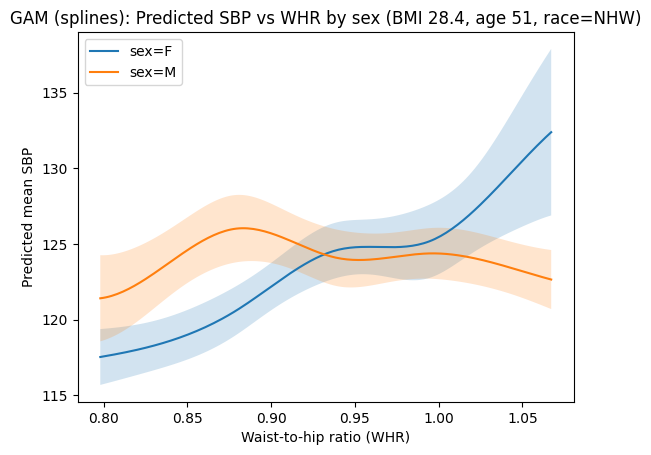


Model comparison (lower AIC better):
                       model          AIC   adj_R2    n
    GAM: + WHR spline by sex 42180.573176 0.284475 4979
          LM: linear WHR*sex 42200.302081 0.279474 4979
GAM: age spline + WHR spline 42210.815874 0.279251 4979
GAM: age spline + linear WHR 42231.755189 0.275489 4979


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# ============================================================
# 0) INPUT
# ============================================================
DATA = df  # <-- change to your dataframe name

# ============================================================
# 1) PREP (same as before)
# ============================================================
d = DATA.copy()
d = d.loc[d["RIDAGEYR"] >= 18].copy()

d["sex"] = d["RIAGENDR"].replace({1: "M", 2: "F"})
d["race"] = d["RIDRETH1"].replace({1: "MA", 2: "OH", 3: "NHW", 4: "NHB", 5: "Other"})

sbp_cols = [c for c in ["BPXSY1","BPXSY2","BPXSY3","BPXSY4"] if c in d.columns]
d["sbp_mean"] = d[sbp_cols].mean(axis=1, skipna=True)

d["whr"] = d["BMXWAIST"] / d["BMXHIP"]

# conservative filters
d = d.dropna(subset=["sbp_mean","RIDAGEYR","sex","race","BMXBMI","whr"]).copy()
d = d.loc[d["sbp_mean"].between(70, 250)].copy()
d = d.loc[d["BMXBMI"].between(12, 70)].copy()
d = d.loc[d["whr"].between(0.5, 1.5)].copy()

print("N (analysis sample) =", len(d))

# ============================================================
# 2) STAGE 1: Baseline LM (interpretable effect sizes)
# ============================================================
f_lm_int = "sbp_mean ~ RIDAGEYR + C(sex) + C(race) + BMXBMI + whr * C(sex)"
m_lm = smf.ols(f_lm_int, data=d).fit(cov_type="HC3")

print("\n=== Baseline LM (linear WHR, with WHR*sex) ===")
print("AIC:", m_lm.aic, "adj_R2:", m_lm.rsquared_adj)

# ============================================================
# 3) STAGE 1 upgrade: "GAM" via spline regression (bs())
#    - smooth age
#    - smooth WHR
#    - allow WHR smooth to differ by sex (interaction in spline space)
#
# Note: patsy bs() uses cubic splines when degree=3.
# ============================================================
K_AGE = 6   # spline df for age (tune: 5-8 usually fine)
K_WHR = 6   # spline df for WHR

# Main-effect spline model (same smooth for both sexes)
f_gam_main = (
    f"sbp_mean ~ bs(RIDAGEYR, df={K_AGE}, degree=3) "
    f"+ C(sex) + C(race) + BMXBMI "
    f"+ bs(whr, df={K_WHR}, degree=3)"
)

# Sex-specific WHR smooth: add bs(whr):C(sex) terms
# This creates a *difference curve* for males relative to females (depending on coding),
# i.e., effect modification in the smooth component.
f_gam_int = (
    f"sbp_mean ~ bs(RIDAGEYR, df={K_AGE}, degree=3) "
    f"+ C(sex) + C(race) + BMXBMI "
    f"+ bs(whr, df={K_WHR}, degree=3) "
    f"+ bs(whr, df={K_WHR}, degree=3):C(sex)"
)

m_gam_main = smf.ols(f_gam_main, data=d).fit(cov_type="HC3")
m_gam_int  = smf.ols(f_gam_int,  data=d).fit(cov_type="HC3")

print("\n=== Spline/GAM-style models ===")
print("GAM main:     AIC:", m_gam_main.aic, "adj_R2:", m_gam_main.rsquared_adj)
print("GAM + sex by: AIC:", m_gam_int.aic,  "adj_R2:", m_gam_int.rsquared_adj)

# ============================================================
# 4) Focused hypothesis checks (optional but nice for memo)
#    (a) Is WHR nonlinear?  Compare GAM main vs linear WHR (no spline)
#    (b) Does WHR shape differ by sex?  Joint test of bs(whr):C(sex) terms
# ============================================================

# (a) nonlinearity check: compare linear WHR model vs spline WHR (same for both sexes)
# linear WHR but still smooth age
f_age_smooth_linear_whr = (
    f"sbp_mean ~ bs(RIDAGEYR, df={K_AGE}, degree=3) "
    f"+ C(sex) + C(race) + BMXBMI + whr"
)
m_age_smooth_linear_whr = smf.ols(f_age_smooth_linear_whr, data=d).fit(cov_type="HC3")

print("\nNonlinearity check (AIC):")
print("Age-smooth + linear WHR AIC:", m_age_smooth_linear_whr.aic)
print("Age-smooth + spline WHR AIC:", m_gam_main.aic)

# (b) sex-specific WHR shape check: joint Wald test on interaction spline columns
int_cols = [c for c in m_gam_int.params.index if "bs(whr" in c and ":C(sex)" in c]
print("\nSpline interaction columns (WHR-by-sex):", len(int_cols))

if len(int_cols) > 0:
    R = np.zeros((len(int_cols), len(m_gam_int.params)))
    param_names = list(m_gam_int.params.index)
    for i, col in enumerate(int_cols):
        R[i, param_names.index(col)] = 1.0
    wald = m_gam_int.wald_test(R)
    print("Joint Wald test for WHR-by-sex spline terms:")
    print("  stat =", float(wald.statistic), "df =", int(wald.df_denom), "p =", float(wald.pvalue))

# ============================================================
# 5) Plot: predicted SBP vs WHR (by sex) from GAM+sex-by model
# ============================================================
age0  = float(d["RIDAGEYR"].median())
bmi0  = float(d["BMXBMI"].median())
race0 = d["race"].value_counts().idxmax()

w_lo, w_hi = d["whr"].quantile([0.05, 0.95]).tolist()
whr_grid = np.linspace(w_lo, w_hi, 160)

plt.figure()
for sx in ["F", "M"]:
    new = pd.DataFrame({
        "RIDAGEYR": age0,
        "BMXBMI": bmi0,
        "race": race0,
        "sex": sx,
        "whr": whr_grid
    })
    pred = m_gam_int.get_prediction(new).summary_frame()
    plt.plot(whr_grid, pred["mean"].values, label=f"sex={sx}")
    plt.fill_between(whr_grid, pred["mean_ci_lower"].values, pred["mean_ci_upper"].values, alpha=0.2)

plt.xlabel("Waist-to-hip ratio (WHR)")
plt.ylabel("Predicted mean SBP")
plt.title(f"GAM (splines): Predicted SBP vs WHR by sex (BMI {bmi0:.1f}, age {age0:.0f}, race={race0})")
plt.legend()
plt.show()

# ============================================================
# 6) Compact comparison table (nice for memo)
# ============================================================
cmp = pd.DataFrame([
    {"model":"LM: linear WHR*sex", "AIC":m_lm.aic, "adj_R2":m_lm.rsquared_adj, "n":int(m_lm.nobs)},
    {"model":"GAM: age spline + linear WHR", "AIC":m_age_smooth_linear_whr.aic, "adj_R2":m_age_smooth_linear_whr.rsquared_adj, "n":int(m_age_smooth_linear_whr.nobs)},
    {"model":"GAM: age spline + WHR spline", "AIC":m_gam_main.aic, "adj_R2":m_gam_main.rsquared_adj, "n":int(m_gam_main.nobs)},
    {"model":"GAM: + WHR spline by sex", "AIC":m_gam_int.aic, "adj_R2":m_gam_int.rsquared_adj, "n":int(m_gam_int.nobs)},
]).sort_values("AIC")

print("\nModel comparison (lower AIC better):")
print(cmp.to_string(index=False))

[DR] Candidate lab cols after nonmissing filter: 40
[DR] Labs used in PCA (after standardization sanity): 39
[DR] Using k=10 PCs; cumulative explained variance ≈ 0.705

[DR] Summary: {'n': 4361, 'p': 39, 'k': 10, 'cum_explained': 0.7046006719263681, 'impute': 'median', 'min_nonmissing': 0.8}

=== DR-adjusted models ===
LM+DR:  AIC: 36862.50067883555 adj_R2: 0.2971042320322297
GAM+DR: AIC: 36827.61298101317 adj_R2: 0.30508402757666
Spline interaction columns (WHR-by-sex): 6
Joint Wald test for WHR-by-sex spline terms:
  stat = 46.69751934482525 df = 6 p = 2.1498993443052075e-08


c:\venvs\si670\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
C:\Users\oscar10408\AppData\Local\Temp\ipykernel_23620\3783546685.py:136: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  wald_out = {"stat": float(wald.statistic), "df": int(wald.df_denom), "p": float(wald.pvalue)}


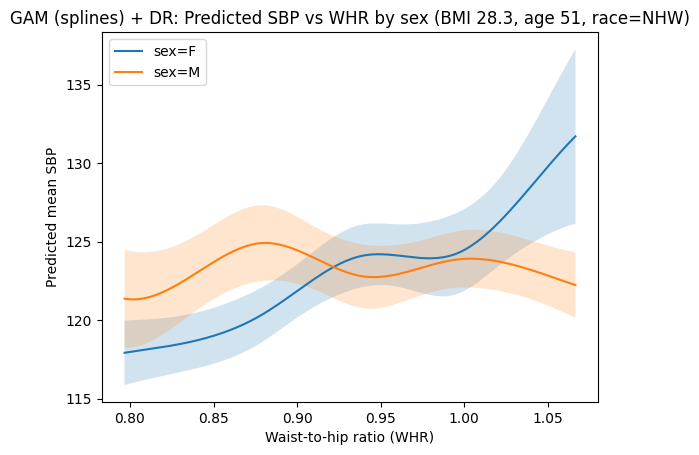


=== Comparison: with vs without DR ===
                             model          AIC   adj_R2    n
GAM: WHR spline by sex + DR (k=10) 36827.612981 0.305084 4361
    LM: linear WHR*sex + DR (k=10) 36862.500679 0.297104 4361
    GAM: WHR spline by sex (no DR) 42180.573176 0.284475 4979
        LM: linear WHR*sex (no DR) 42200.302081 0.279474 4979


In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

def add_pca_components(
    d,
    lab_prefixes=("LBX", "LBD"),
    min_nonmissing=0.80,
    var_target=0.80,
    k_max=10,
    impute="median",   # "median" recommended; or "mean"
    verbose=True
):
    """
    Returns:
      d_out: dataframe with PC1..PCk added
      info: dict with lab_cols_used, k, explained_variance (cum), etc.
    """
    d = d.copy()

    # 1) collect candidate labs
    lab_cols = []
    for c in d.columns:
        if any(c.startswith(p) for p in lab_prefixes) and pd.api.types.is_numeric_dtype(d[c]):
            lab_cols.append(c)

    # keep labs with enough observed values
    lab_cols = [c for c in lab_cols if d[c].notna().mean() >= min_nonmissing]

    if verbose:
        print(f"[DR] Candidate lab cols after nonmissing filter: {len(lab_cols)}")

    if len(lab_cols) == 0:
        raise ValueError("No lab columns available for PCA under current filters.")

    X = d[lab_cols].astype(float).copy()

    # 2) simple imputation (to avoid huge N loss)
    if impute == "median":
        fill_vals = X.median()
    elif impute == "mean":
        fill_vals = X.mean()
    else:
        raise ValueError("impute must be 'median' or 'mean'")

    X = X.fillna(fill_vals)

    # 3) standardize
    mu = X.mean(axis=0)
    sd = X.std(axis=0, ddof=0).replace(0, np.nan)
    Xz = (X - mu) / sd
    # drop any columns that ended up with nan (e.g., zero variance)
    keep = Xz.columns[Xz.notna().all(axis=0)]
    Xz = Xz[keep]
    lab_cols_used = list(Xz.columns)

    if verbose:
        print(f"[DR] Labs used in PCA (after standardization sanity): {len(lab_cols_used)}")

    # 4) PCA via SVD
    # Xz is (n x p)
    U, S, Vt = np.linalg.svd(Xz.values, full_matrices=False)

    # explained variance ratio
    eig = (S**2) / (Xz.shape[0] - 1)
    evr = eig / eig.sum()
    cum = np.cumsum(evr)

    k = int(np.searchsorted(cum, var_target) + 1)
    k = min(k, k_max)

    if verbose:
        print(f"[DR] Using k={k} PCs; cumulative explained variance ≈ {cum[k-1]:.3f}")

    # PC scores: U*S
    PC = U[:, :k] * S[:k]
    for j in range(k):
        d[f"PC{j+1}"] = PC[:, j]

    info = {
        "lab_cols_used": lab_cols_used,
        "k": k,
        "cum_explained": float(cum[k-1]),
        "evr_first10": evr[:min(10, len(evr))],
        "n": int(Xz.shape[0]),
        "p": int(Xz.shape[1]),
        "impute": impute,
        "min_nonmissing": min_nonmissing
    }
    return d, info


def fit_models_with_dr(d, K_AGE=6, K_WHR=6, verbose=True):
    """
    Requires in d:
      sbp_mean, RIDAGEYR, sex, race, BMXBMI, whr, and PC1..PCk
    """
    pc_cols = [c for c in d.columns if c.startswith("PC")]
    if len(pc_cols) == 0:
        raise ValueError("No PCs found. Run add_pca_components first.")

    pc_terms = " + ".join(pc_cols)

    # Baseline LM with DR
    f_lm_dr = f"sbp_mean ~ RIDAGEYR + C(sex) + C(race) + BMXBMI + whr * C(sex) + {pc_terms}"
    m_lm_dr = smf.ols(f_lm_dr, data=d).fit(cov_type="HC3")

    # GAM-style spline with sex-specific WHR smooth + DR
    f_gam_dr = (
        f"sbp_mean ~ bs(RIDAGEYR, df={K_AGE}, degree=3) "
        f"+ C(sex) + C(race) + BMXBMI "
        f"+ bs(whr, df={K_WHR}, degree=3) "
        f"+ bs(whr, df={K_WHR}, degree=3):C(sex) "
        f"+ {pc_terms}"
    )
    m_gam_dr = smf.ols(f_gam_dr, data=d).fit(cov_type="HC3")

    if verbose:
        print("\n=== DR-adjusted models ===")
        print("LM+DR:  AIC:", m_lm_dr.aic, "adj_R2:", m_lm_dr.rsquared_adj)
        print("GAM+DR: AIC:", m_gam_dr.aic, "adj_R2:", m_gam_dr.rsquared_adj)

    # Joint test for WHR-by-sex spline terms (shape differs by sex)
    int_cols = [c for c in m_gam_dr.params.index if "bs(whr" in c and ":C(sex)" in c]
    if verbose:
        print("Spline interaction columns (WHR-by-sex):", len(int_cols))

    wald_out = None
    if len(int_cols) > 0:
        R = np.zeros((len(int_cols), len(m_gam_dr.params)))
        param_names = list(m_gam_dr.params.index)
        for i, col in enumerate(int_cols):
            R[i, param_names.index(col)] = 1.0
        wald = m_gam_dr.wald_test(R)
        wald_out = {"stat": float(wald.statistic), "df": int(wald.df_denom), "p": float(wald.pvalue)}
        if verbose:
            print("Joint Wald test for WHR-by-sex spline terms:")
            print("  stat =", wald_out["stat"], "df =", wald_out["df"], "p =", wald_out["p"])

    return m_lm_dr, m_gam_dr, wald_out


def plot_gam_dr_curve(d, m_gam_dr, title_prefix="GAM+DR", whr_q=(0.05, 0.95)):
    """
    Plots predicted SBP vs WHR by sex, fixing:
      age = median, BMI = median, race = mode,
      PCs fixed at 0 (interpretable because PCs are centered).
    """
    age0  = float(d["RIDAGEYR"].median())
    bmi0  = float(d["BMXBMI"].median())
    race0 = d["race"].value_counts().idxmax()

    w_lo, w_hi = d["whr"].quantile(list(whr_q)).tolist()
    whr_grid = np.linspace(w_lo, w_hi, 160)

    pc_cols = [c for c in d.columns if c.startswith("PC")]
    pc_zero = {c: 0.0 for c in pc_cols}  # centered baseline

    plt.figure()
    for sx in ["F", "M"]:
        new = pd.DataFrame({
            "RIDAGEYR": age0,
            "BMXBMI": bmi0,
            "race": race0,
            "sex": sx,
            "whr": whr_grid,
            **pc_zero
        })
        pred = m_gam_dr.get_prediction(new).summary_frame()
        plt.plot(whr_grid, pred["mean"].values, label=f"sex={sx}")
        plt.fill_between(whr_grid, pred["mean_ci_lower"].values, pred["mean_ci_upper"].values, alpha=0.2)

    plt.xlabel("Waist-to-hip ratio (WHR)")
    plt.ylabel("Predicted mean SBP")
    plt.title(f"{title_prefix}: Predicted SBP vs WHR by sex (BMI {bmi0:.1f}, age {age0:.0f}, race={race0})")
    plt.legend()
    plt.show()


# ============================================================
# HOW TO USE (assumes you already created d as in your GAM run)
# d must contain: sbp_mean, RIDAGEYR, sex, race, BMXBMI, whr
# ============================================================

# 1) Add PCA components from labs
d_dr, dr_info = add_pca_components(
    d,
    lab_prefixes=("LBX", "LBD"),
    min_nonmissing=0.80,
    var_target=0.80,
    k_max=10,
    impute="median",
    verbose=True
)

print("\n[DR] Summary:", {k: dr_info[k] for k in ["n","p","k","cum_explained","impute","min_nonmissing"]})

# 2) Fit DR-adjusted LM and GAM
m_lm_dr, m_gam_dr, wald_dr = fit_models_with_dr(d_dr, K_AGE=6, K_WHR=6, verbose=True)

# 3) Plot DR-adjusted GAM curve
plot_gam_dr_curve(d_dr, m_gam_dr, title_prefix="GAM (splines) + DR")

# 4) Small comparison table (paste into memo)
cmp_dr = pd.DataFrame([
    {"model":"LM: linear WHR*sex (no DR)", "AIC": m_lm.aic, "adj_R2": m_lm.rsquared_adj, "n": int(m_lm.nobs)},
    {"model":"GAM: WHR spline by sex (no DR)", "AIC": m_gam_int.aic, "adj_R2": m_gam_int.rsquared_adj, "n": int(m_gam_int.nobs)},
    {"model":f"LM: linear WHR*sex + DR (k={dr_info['k']})", "AIC": m_lm_dr.aic, "adj_R2": m_lm_dr.rsquared_adj, "n": int(m_lm_dr.nobs)},
    {"model":f"GAM: WHR spline by sex + DR (k={dr_info['k']})", "AIC": m_gam_dr.aic, "adj_R2": m_gam_dr.rsquared_adj, "n": int(m_gam_dr.nobs)},
]).sort_values("AIC")

print("\n=== Comparison: with vs without DR ===")
print(cmp_dr.to_string(index=False))

In [34]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from patsy import bs
import matplotlib.pyplot as plt

# 如果你要更貼近老師 sbp_gam：用 GLMGam + BSplines
from statsmodels.gam.api import GLMGam, BSplines

# 如果你要更貼近老師 sbp_dr：用 SIR
from statsmodels.regression.dimred import SIR

# -----------------------------
# 0) Utilities
# -----------------------------
def make_ref_profile(d):
    """Reference point for prediction plots: median/most common."""
    return {
        "RIDAGEYR": float(d["RIDAGEYR"].median()),
        "BMXBMI": float(d["BMXBMI"].median()),
        "race": d["race"].value_counts().idxmax(),
    }

def safe_wald_test(res, cols):
    """Joint Wald test for selected coefficients."""
    if len(cols) == 0:
        return None
    param_names = list(res.params.index)
    R = np.zeros((len(cols), len(param_names)))
    for i, c in enumerate(cols):
        R[i, param_names.index(c)] = 1.0
    # scalar=True avoids future warning
    return res.wald_test(R, scalar=True)

# -----------------------------
# 1) Data prep (do once)
# -----------------------------
def prepare_data(df):
    d = df.copy()

    # Example: build SBP mean, sex/race labels, WHR
    # (replace with your existing code)
    d = d.dropna(subset=["BPXSY1", "RIDAGEYR", "RIAGENDR", "BMXBMI", "BMXWAIST", "BMXHIP"])
    d["sbp"] = d["BPXSY1"]
    d["sex"] = d["RIAGENDR"]  # already F/M
    # race: map RIDRETH1 -> labels (use your existing mapping)
    d["race"] = d["RIDRETH1"]  # placeholder
    d["whr"] = d["BMXWAIST"] / d["BMXHIP"]

    # optional: trim extremes to stabilize plots
    d = d[(d["RIDAGEYR"] >= 18) & (d["RIDAGEYR"] <= 80)]
    return d

# -----------------------------
# 2) LM suite (matches sbp_lm spirit: nested models + AIC)
# -----------------------------
def fit_lm_suite(d):
    f_base = "sbp ~ RIDAGEYR + C(sex) + C(race) + BMXBMI"
    f_whr  = "sbp ~ RIDAGEYR + C(sex) + C(race) + BMXBMI + whr"
    f_int  = "sbp ~ RIDAGEYR + C(sex) + C(race) + BMXBMI + whr * C(sex)"

    m0 = smf.ols(f_base, data=d).fit(cov_type="HC3")
    m1 = smf.ols(f_whr,  data=d).fit(cov_type="HC3")
    m2 = smf.ols(f_int,  data=d).fit(cov_type="HC3")
    return {"lm_base": m0, "lm_whr": m1, "lm_whr_sex": m2}

# -----------------------------
# 3) GAM suite
#    Option A: stay with patsy bs() (你現在的寫法)
#    Option B: GLMGam + BSplines (更貼近 sbp_gam)
# -----------------------------
def fit_gam_patsy(d, K_AGE=6, K_WHR=6):
    f = (
        f"sbp ~ bs(RIDAGEYR, df={K_AGE}, degree=3)"
        f" + C(sex) + C(race) + BMXBMI"
        f" + bs(whr, df={K_WHR}, degree=3)"
        f" + bs(whr, df={K_WHR}, degree=3):C(sex)"
    )
    mg = smf.ols(f, data=d).fit(cov_type="HC3")

    # joint test: are WHR spline-by-sex terms jointly 0?
    int_cols = [c for c in mg.params.index if "bs(whr" in c and ":C(sex)" in c]
    wald = safe_wald_test(mg, int_cols)
    return mg, wald

def fit_gam_glmgam(d, df_age=10, df_whr=10, alpha_age=20., alpha_whr=20.):
    # build spline bases for age and whr
    x_spline = d[["RIDAGEYR", "whr"]]
    bspl = BSplines(x_spline, df=[df_age, df_whr], degree=[3, 3])

    # parametric part (linear / categorical)
    # NOTE: GLMGam formula cannot directly do "smooth-by-sex" like mgcv;
    # workaround: fit separate GAM by sex (sex-stratified) or add interaction manually.
    f = "sbp ~ C(sex) + C(race) + BMXBMI"
    mod = GLMGam.from_formula(f, data=d, smoother=bspl, alpha=np.r_[alpha_age, alpha_whr])
    res = mod.fit()
    return res

# -----------------------------
# 4) DR adjustment
#    A) PCA on labs (你目前做的)
#    B) SIR score on anthropometrics (貼近 sbp_dr)
# -----------------------------
def add_sir_scores(d, vx):
    # vx: list of numeric predictors (anthropometrics, etc.)
    dx = d.dropna(subset=["sbp"] + vx).copy()
    y = dx["sbp"].to_numpy()
    X = dx[vx].to_numpy()

    # mean-center like sbp_dr emphasizes
    X = X - X.mean(axis=0, keepdims=True)
    y = y - y.mean()

    sir = SIR(y, X).fit()
    scores = X @ sir.params  # (n x ndirs)
    dx["SIR1"] = scores[:, 0]
    if scores.shape[1] > 1:
        dx["SIR2"] = scores[:, 1]
    return dx, sir

# -----------------------------
# 5) Plot: predicted SBP vs WHR by sex
# -----------------------------
def plot_pred_curve(d, model, ref, title,
                    whr_q=(0.05, 0.95),
                    fix_numeric="mean",   # or "median" or 0
                    fix_categorical="mode"):

    # WHR grid
    whr_grid = np.linspace(d["whr"].quantile(whr_q[0]), d["whr"].quantile(whr_q[1]), 80)

    # Start building base row dict (shared across sexes)
    base = {
        "RIDAGEYR": ref["RIDAGEYR"],
        "BMXBMI": ref["BMXBMI"],
        "race": ref["race"],
    }

    # Identify all columns that the model might need (simple heuristic):
    # include any numeric column names that appear in d AND are referenced in model params/design
    # Safer: just ensure *all* numeric columns in d that are not outcomes are available with defaults.
    needed = set()

    # Patsy stores design_info with factor names; easiest robust trick:
    try:
        di = model.model.data.design_info
        # factor_infos keys look like 'SIR1', 'C(sex)', 'bs(whr, ...)' etc.
        # We only want raw variable names that should exist in `new`.
        for term in di.term_names:
            # Keep simple raw vars likely needed
            for v in ["SIR1", "SIR2", "PC1", "PC2"]:  # optional quick pass
                if v in term:
                    needed.add(v)
    except Exception:
        pass

    # Also: if the model was fit with extra columns (like SIR1) present in d,
    # make sure they're included in new by defaulting to mean/median/0.
    extra_numeric_candidates = [c for c in d.columns if c not in ["sbp", "sbp_mean"]]
    for c in extra_numeric_candidates:
        if c.startswith("SIR") or c.startswith("PC"):
            needed.add(c)

    # Decide default value for any needed numeric columns
    def default_numeric(col):
        if fix_numeric == "mean":
            return float(d[col].mean())
        if fix_numeric == "median":
            return float(d[col].median())
        if fix_numeric == 0:
            return 0.0
        raise ValueError("fix_numeric must be 'mean', 'median', or 0")

    for c in needed:
        if c in d.columns and c not in base:
            base[c] = default_numeric(c)

    plt.figure()
    for sx in ["F", "M"]:
        new = pd.DataFrame({
            **base,
            "sex": sx,
            "whr": whr_grid
        })
        pred = model.get_prediction(new).summary_frame()
        plt.plot(whr_grid, pred["mean"].to_numpy(), label=f"sex={sx}")
        plt.fill_between(
            whr_grid,
            pred["mean_ci_lower"].to_numpy(),
            pred["mean_ci_upper"].to_numpy(),
            alpha=0.2
        )

    plt.xlabel("Waist-to-hip ratio (WHR)")
    plt.ylabel("Predicted mean SBP")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# -----------------------------
# 6) One-click runner
# -----------------------------
def run_all(df, use_sir=False):
    d = prepare_data(df)
    ref = make_ref_profile(d)

    # LM
    lms = fit_lm_suite(d)

    # GAM (patsy version, matches what you already wrote)
    mg, wald = fit_gam_patsy(d, K_AGE=6, K_WHR=6)

    plot_pred_curve(d, mg, ref, "GAM: Predicted SBP vs WHR by sex (ref profile)")
    if wald is not None:
        print("Wald test (WHR smooth differs by sex): p =", float(wald.pvalue))

    # Optional DR via SIR (anthropometrics)
    if use_sir:
        vx = ["BMXBMI", "BMXWAIST", "BMXHIP"]  # + more anthropometrics if you want
        d_sir, sir = add_sir_scores(d, vx=vx)

        # refit GAM with SIR scores as adjustment
        f_dr = (
            "sbp ~ bs(RIDAGEYR, df=6, degree=3)"
            " + C(sex) + C(race) + BMXBMI"
            " + bs(whr, df=6, degree=3) + bs(whr, df=6, degree=3):C(sex)"
            " + SIR1"
        )
        m_dr = smf.ols(f_dr, data=d_sir).fit(cov_type="HC3")
        plot_pred_curve(d_sir, m_dr, make_ref_profile(d_sir),
                        "GAM + DR(SIR): Predicted SBP vs WHR by sex")

    return d, lms, mg


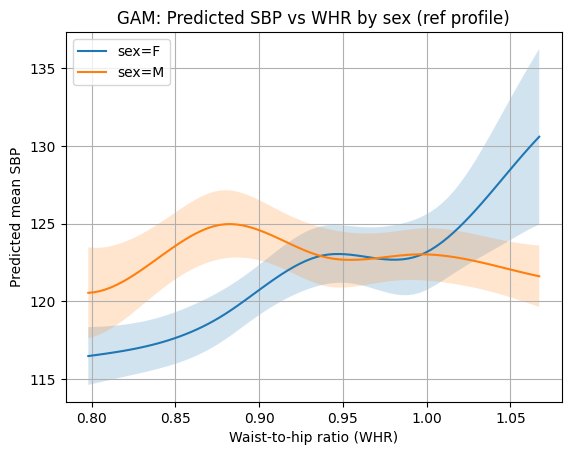

Wald test (WHR smooth differs by sex): p = 7.151876444092371e-08


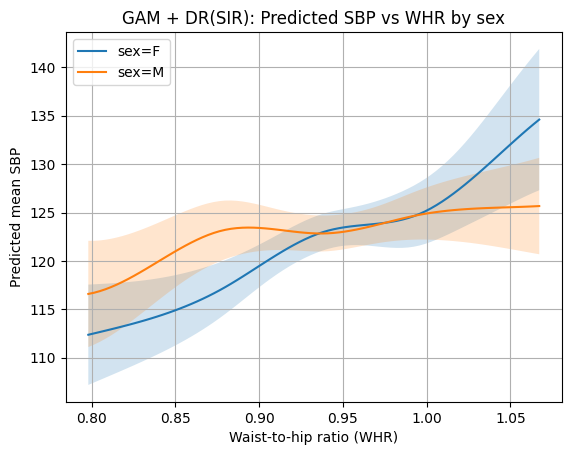

(          SEQN  SDDSRVYR  RIDSTATR RIAGENDR  RIDAGEYR  RIDAGEMN RIDRETH1  \
 3      93706.0      10.0       2.0        M      18.0       NaN    Other   
 6      93709.0      10.0       2.0        F      75.0       NaN      NHB   
 8      93711.0      10.0       2.0        M      56.0       NaN    Other   
 9      93712.0      10.0       2.0        M      18.0       NaN       MA   
 10     93713.0      10.0       2.0        M      67.0       NaN      NHW   
 ...        ...       ...       ...      ...       ...       ...      ...   
 9246  102949.0      10.0       2.0        M      33.0       NaN      NHW   
 9249  102952.0      10.0       2.0        F      70.0       NaN    Other   
 9250  102953.0      10.0       2.0        M      42.0       NaN       MA   
 9251  102954.0      10.0       2.0        F      41.0       NaN      NHB   
 9253  102956.0      10.0       2.0        M      38.0       NaN      NHW   
 
       RIDRETH3  RIDEXMON  RIDEXAGM  ...  LBDSTPSI  LBXSTR  LBDSTRSI  LBXS

In [37]:
run_all(d, use_sir=True)

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.regression.dimred import SIR
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.interpolate import interp1d

def fit_sir_scores(d, y_col="sbp", vx=None, sex_col="sex", ndirs=2):
    """
    d: DataFrame needs y_col and vx columns.
    vx: predictors used for DR (recommend use same 10 anthropometric+demo as sbp_dr).
    Returns: dx (cleaned/centered), scores (n x ndirs), fitted SIR result
    """
    if vx is None:
        vx = ["RIDAGEYR", "BMXWT", "BMXHT", "BMXBMI", "BMXLEG",
              "BMXARML", "BMXARMC", "BMXWAIST", "BMXHIP", sex_col]

    use = [y_col] + vx
    dx = d.loc[:, use].dropna().copy()

    # numeric code sex like sbp_dr: F->1, M->-1 (you can flip, doesn't matter up to sign)
    if sex_col in dx.columns and dx[sex_col].dtype == "O":
        dx[sex_col + "_x"] = dx[sex_col].replace({"F": 1, "M": -1}).astype(float)
        vx2 = [c for c in vx if c != sex_col] + [sex_col + "_x"]
    else:
        vx2 = vx

    # mean-center float columns (sbp_dr style)
    for c in [y_col] + vx2:
        if np.issubdtype(dx[c].dtype, np.number):
            dx[c] = dx[c] - dx[c].mean()

    y = np.asarray(dx[y_col])
    X = np.asarray(dx[vx2])

    m = SIR(y, X)
    r = m.fit(ndirs=ndirs)
    scores = X @ r.params   # (n x ndirs)

    return dx, scores, r, vx2

In [39]:
def plot_stratified_lowess(dx, scores, j=1, k=0, y_col="sbp", q=5, frac=0.25):
    """
    Stratify on score j (q groups), plot LOWESS of y vs score k within each stratum.
    Mimics sbp_dr plotstrat.
    """
    dp = pd.DataFrame({
        "strat": scores[:, j],
        "x": scores[:, k],
        "y": dx[y_col].to_numpy()
    })

    # qcut groups
    dp["strat_bin"] = pd.qcut(dp["strat"], q, duplicates="drop")

    plt.figure(figsize=(7, 4))
    ax = plt.axes([0.12, 0.12, 0.65, 0.8])
    ax.grid(True)

    for ky, dv in dp.groupby("strat_bin", observed=True):
        dv = dv.sort_values("x")
        sm = lowess(dv["y"], dv["x"], frac=frac, return_sorted=True)
        # interpolate to a smooth line over x-range
        f = interp1d(sm[:, 0], sm[:, 1], bounds_error=False, fill_value="extrapolate")
        xx = np.linspace(dv["x"].min(), dv["x"].max(), 200)
        lab = f"{ky.left:.2f}–{ky.right:.2f}"
        ax.plot(xx, f(xx), "-", label=lab)

    ha, lb = ax.get_legend_handles_labels()
    leg = plt.figlegend(ha, lb, loc="center right")
    leg.draw_frame(False)
    leg.set_title(f"Score {j+1} strata")

    ax.set_xlabel(f"Score {k+1}", size=13)
    ax.set_ylabel(f"{y_col} (centered)", size=13)
    plt.show()

C:\Users\oscar10408\AppData\Local\Temp\ipykernel_23620\564468296.py:24: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dx[sex_col + "_x"] = dx[sex_col].replace({"F": 1, "M": -1}).astype(float)
c:\venvs\si670\Lib\site-packages\statsmodels\regression\dimred.py:67: UserWarning: SIR.fit does not take any extra keyword arguments
  warnings.warn(msg)


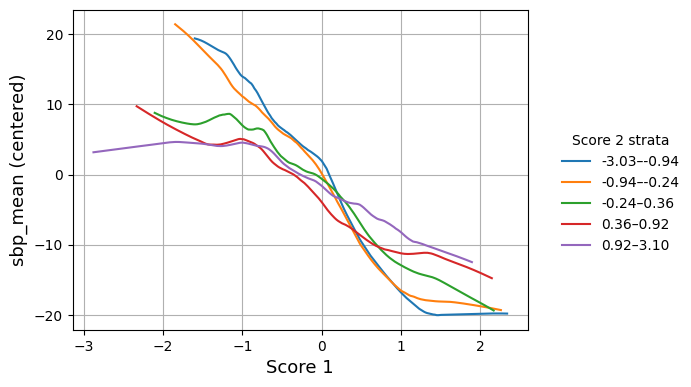

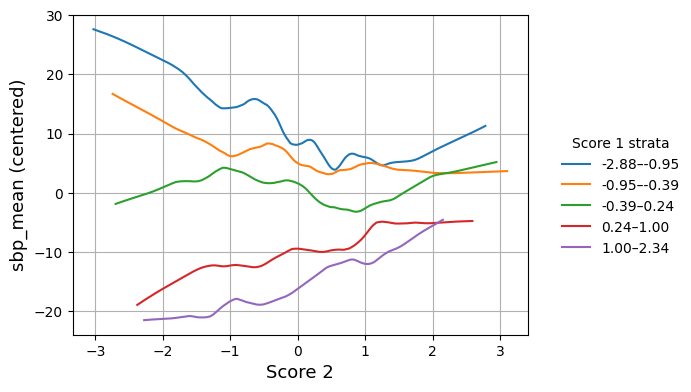

In [49]:
dx, scores, r, vx2 = fit_sir_scores(d, y_col="sbp_mean", ndirs=2)
plot_stratified_lowess(dx, scores, j=1, k=0, y_col="sbp_mean", q=5)  # strat score2, plot vs score1
plot_stratified_lowess(dx, scores, j=0, k=1, y_col="sbp_mean", q=5)  # strat score1, plot vs score2

In [ ]:
def plot_score_vs_var(dx, scores, var, score_idx=0, sex_col="sex", frac=0.25):
    """
        Scatter var vs score (or score vs var), overlay LOWESS for F/M.
    """
    dp = pd.DataFrame({
        "x": dx[var],
        "score": scores[:, score_idx],
        "sex": dx[sex_col] if sex_col in dx.columns else "All"
    }).dropna()

    plt.figure(figsize=(7, 5))
    plt.grid(True)

    # If sex not present, just plot one group
    groups = ["F", "M"] if sex_col in dp.columns and dp["sex"].nunique() > 1 else ["All"]
    for g in groups:
        if g == "All":
            dg = dp
        else:
            dg = dp.loc[dp["sex"] == g, :]

        dg = dg.sort_values("x")
        plt.plot(dg["x"], dg["score"], "o", mfc="none", alpha=0.20, label=g)

        sm = lowess(dg["score"], dg["x"], frac=frac, return_sorted=True)
        plt.plot(sm[:, 0], sm[:, 1], "-", linewidth=2)

    plt.xlabel(var, size=13)
    plt.ylabel(f"Score {score_idx+1}", size=13)
    plt.legend()
    plt.show()

In [51]:
def plot_score_vs_var(dx, scores, var, score_idx=0, sex_col="sex", frac=0.25):
    """
    Scatter var vs score (or score vs var), overlay LOWESS for F/M.
    """
    dp = pd.DataFrame({
        "x": dx[var],
        "score": scores[:, score_idx],
        "sex": dx[sex_col] if sex_col in dx.columns else "All"
    }).dropna()

    plt.figure(figsize=(7, 5))
    plt.grid(True)

    # If sex not present, just plot one group
    groups = ["F", "M"] if sex_col in dp.columns and dp["sex"].nunique() > 1 else ["All"]
    for g in groups:
        if g == "All":
            dg = dp
        else:
            dg = dp.loc[dp["sex"] == g, :]

        dg = dg.sort_values("x")
        plt.plot(dg["x"], dg["score"], "o", mfc="none", alpha=0.20, label=g)

        sm = lowess(dg["score"], dg["x"], frac=frac, return_sorted=True)
        plt.plot(sm[:, 0], sm[:, 1], "-", linewidth=2)

    plt.xlabel(var, size=13)
    plt.ylabel(f"Score {score_idx+1}", size=13)
    plt.legend()
    plt.show()

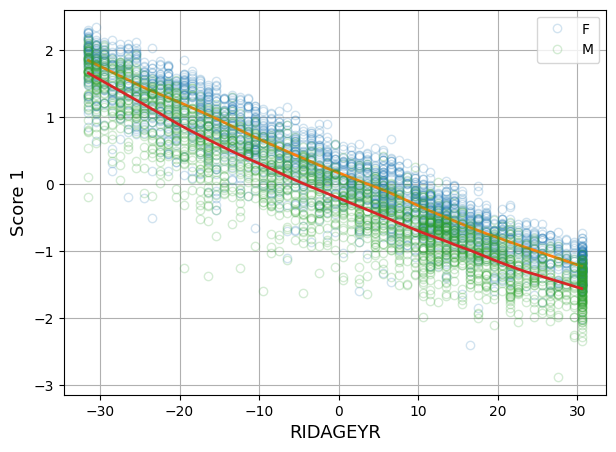

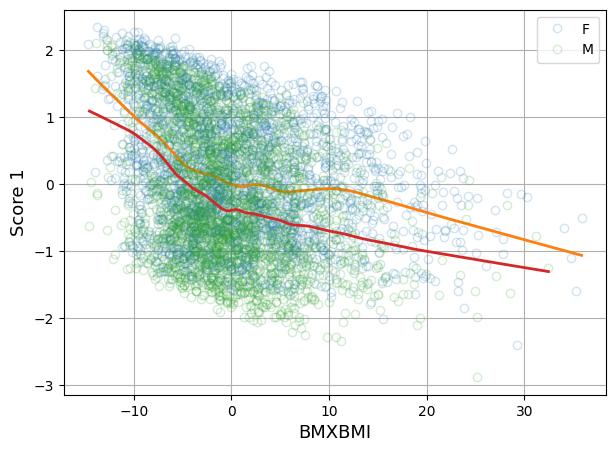

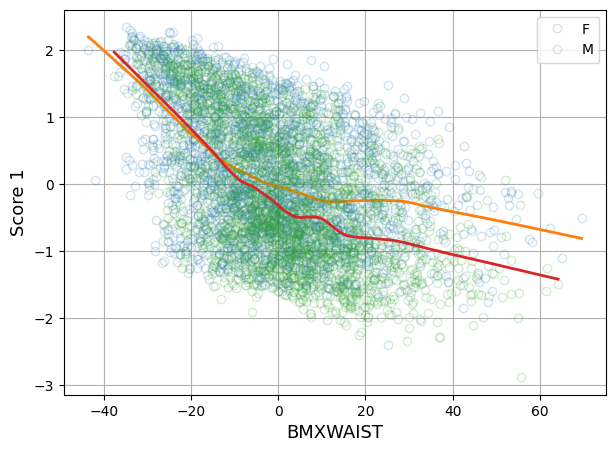

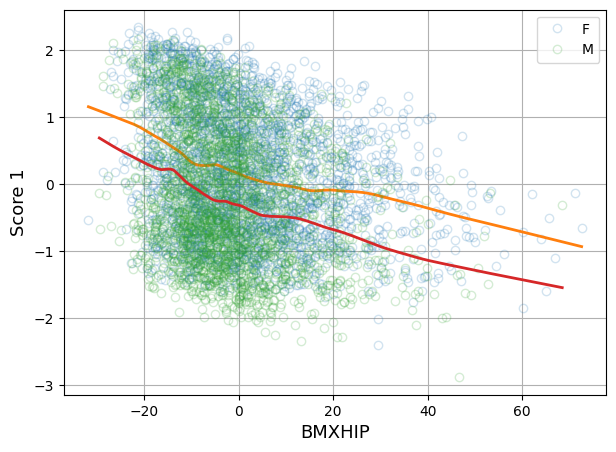

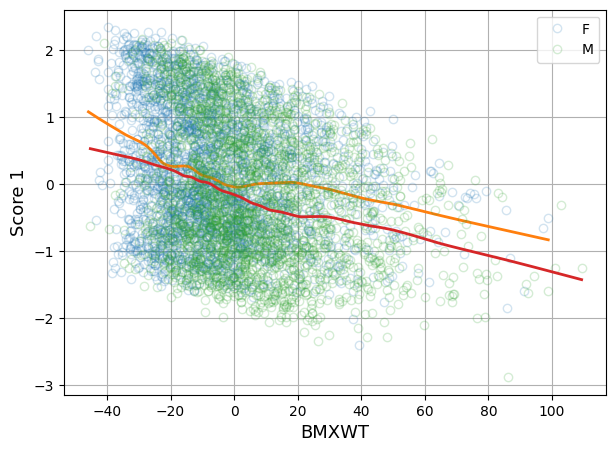

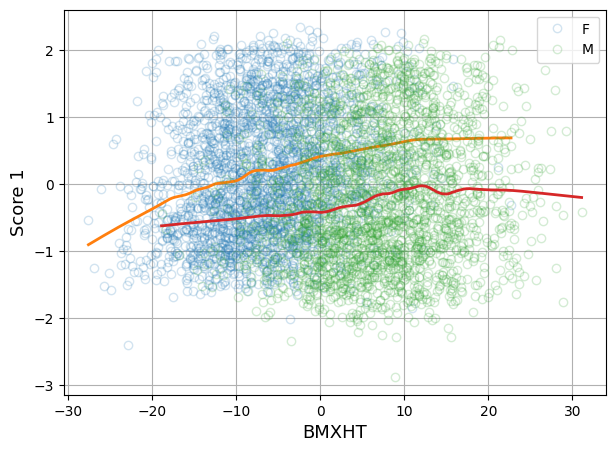

In [ ]:
for v in ["RIDAGEYR", "BMXBMI", "BMXWAIST", "BMXHIP", "BMXWT", "BMXHT"]:
    plot_score_vs_var(dx, scores, v, score_idx=0, sex_col="sex")  # Score1